loading datasets . . .
printing example sample!


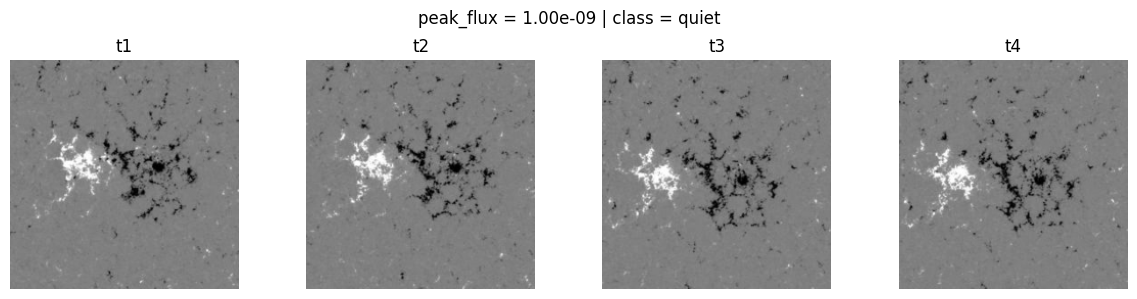

loading current models . . .
loaded current baseline model
loaded current temporal attention model
loaded current frame-difference model
summarizing errors . . .

Baseline:
Mean: 0.0002147712511838342
Std: 0.00019024571031742296
Median: 0.00014878723187539133
90th percentile: 0.00043466138511121243
95th percentile: 0.0004937001097438769
99th percentile: 0.0008931428502683047
Max: 0.00091546203134385


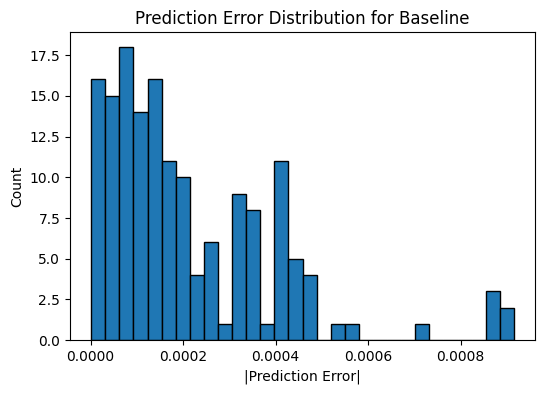

summarizing errors . . .

Attention:
Mean: 0.00027335722832502653
Std: 5.933623484067326e-06
Median: 0.0002730900200625941
90th percentile: 0.00027708203949081687
95th percentile: 0.00028188467999614716
99th percentile: 0.00029652559484920625
Max: 0.00030050978647377935


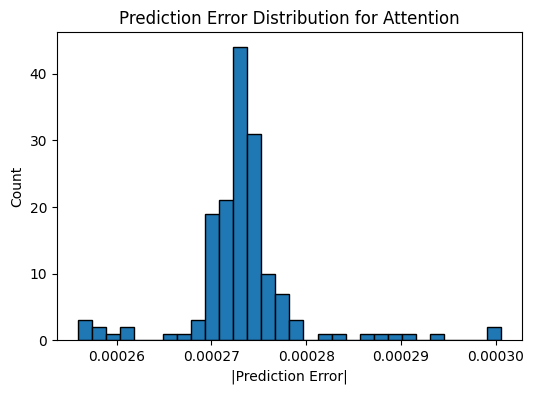

printing grad-cam example: 


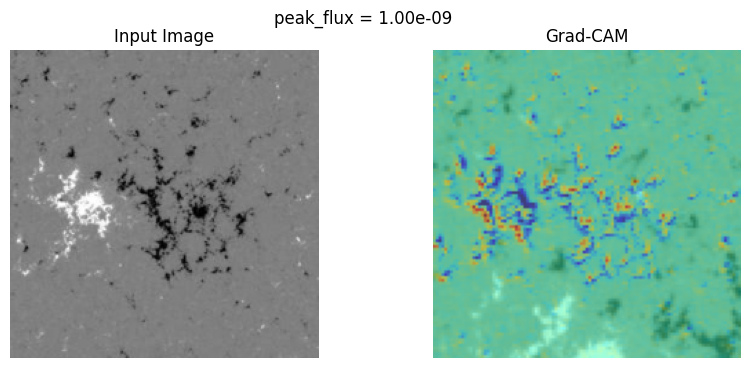

In [35]:
import os
from pathlib import Path
import pandas as pd
import os
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

%run project.ipynb

In [11]:
train_loader = DataLoader(train_seq, batch_size=8, shuffle=True)
val_loader = DataLoader(val_seq, batch_size=8, shuffle=False)
test_loader = DataLoader(test_sequence, batch_size=8, shuffle=False)

train_loader_single = DataLoader(train_sin, batch_size=8, shuffle=True)
val_loader_single = DataLoader(train_sin, batch_size=8, shuffle=False)
test_loader_single = DataLoader(test_single, batch_size=8, shuffle=False)

In [10]:
# train in epochs
epochs = 10

## Baseline Training

In [12]:
# make model with L1 loss function (MAE)
model = BaselineCNN().to(device)
loss_fn = nn.L1Loss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    # training
    model.train()
    # accumulate loss
    train_loss = 0
    # for input images and labels
    for x, y, z in train_loader_single:
        # move data to device
        x = x.to(device).float()
        y = y.to(device).float()
        # reset gradients - torch accumulates and stacks gradients by defualt
        # clears old gradients in between batches
        optimizer.zero_grad()
        # forward pass, we get predictions
        preds = model(x)
        # compute loss 
        loss = loss_fn(preds, y)
        # backward propagation (computes gradients of loss for all model parameters)
        # learning signal
        loss.backward()
        # update weights/model params using gradients
        optimizer.step()
        # acc loss
        train_loss += loss.item()
    # average loss
    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, z in val_loader_single:
            # move data to device
            x = x.to(device).float()
            y = y.to(device).float()
            # prediciton
            preds = model(x)
            # loss 
            loss = loss_fn(preds, y)
            # acc loss
            val_loss += loss.item()
    # average validation los
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch 1/10 | Train Loss: 0.004314 | Val Loss: 0.016031
Epoch 2/10 | Train Loss: 0.001528 | Val Loss: 0.020293
Epoch 3/10 | Train Loss: 0.001131 | Val Loss: 0.007863
Epoch 4/10 | Train Loss: 0.002624 | Val Loss: 0.006086
Epoch 5/10 | Train Loss: 0.000773 | Val Loss: 0.001762
Epoch 6/10 | Train Loss: 0.001128 | Val Loss: 0.009920
Epoch 7/10 | Train Loss: 0.001278 | Val Loss: 0.014239
Epoch 8/10 | Train Loss: 0.000848 | Val Loss: 0.006811
Epoch 9/10 | Train Loss: 0.000561 | Val Loss: 0.001982
Epoch 10/10 | Train Loss: 0.000426 | Val Loss: 0.003390


In [14]:
model.eval()
test_loss = 0
with torch.no_grad():
    for x, y, z in test_loader_single:
        x = x.to(device).float()
        y = y.to(device).float()

        preds = model(x)
        loss = loss_fn(preds, y)

        test_loss += loss.item()

test_loss /= len(test_loader)

print("Final Test Loss:", test_loss)

Final Test Loss: 0.0006511920286217132


In [15]:
torch.save(model.state_dict(), "baseline_2.pth")

## Temporal Attention Training

In [22]:
# use baseline cnn as shared encoder inside temporal model
model = AttentionTemporalCNN().to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    # training
    model.train()
    train_loss = 0
    for x, y , z in train_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()
        optimizer.zero_grad()
        preds, attn = model(x)     # unpack outputs
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, z in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()
            preds, attn = model(x)
            loss = loss_fn(preds, y)
            val_loss += loss.item()
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

Epoch 1/10 | Train: 0.005078 | Val: 0.000281
Epoch 2/10 | Train: 0.000232 | Val: 0.000117
Epoch 3/10 | Train: 0.000276 | Val: 0.000464
Epoch 4/10 | Train: 0.000218 | Val: 0.000252
Epoch 5/10 | Train: 0.000176 | Val: 0.000206
Epoch 6/10 | Train: 0.000206 | Val: 0.000109
Epoch 7/10 | Train: 0.000171 | Val: 0.000103
Epoch 8/10 | Train: 0.000113 | Val: 0.000006
Epoch 9/10 | Train: 0.000144 | Val: 0.000395
Epoch 10/10 | Train: 0.000150 | Val: 0.000273


In [23]:
test_loss = 0
all_preds = []
all_targets = []
all_attn = []
model.eval()

with torch.no_grad():
    for x, y, z in test_loader:
        x = x.to(device).float()
        y = y.to(device).float()

        preds, attn = model(x)
        loss = loss_fn(preds, y)
        test_loss += loss.item()

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())
        all_attn.append(attn.cpu())

test_loss /= len(test_loader)

print(f"Final Test Loss: {test_loss:.6f}")

all_attn = torch.cat(all_attn, dim=0)   # [N, 4, 1]
mean_attn = all_attn.mean(dim=0).squeeze()  # [4]
print(mean_attn)

Final Test Loss: 0.000270
tensor([0.2500, 0.2500, 0.2500, 0.2500])


In [24]:
torch.save(model.state_dict(), "attention_2.pth")

## Frame Difference Training

In [37]:
base_cnn = BaselineCNN().to(device)
model = FrameDiffModel(base_cnn).to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    # training
    model.train()
    train_loss = 0
    for x, y, _ in train_loader:
        x = x.to(device).float()   # [B, 4, 1, H, W]
        y = y.to(device).float()
        optimizer.zero_grad()
        preds = model(x)           # [B]
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y, _ in val_loader:
            x = x.to(device).float()
            y = y.to(device).float()
            preds = model(x)
            loss = loss_fn(preds, y)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}/{epochs} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

Epoch 1/10 | Train: 0.012996 | Val: 0.008416
Epoch 2/10 | Train: 0.004043 | Val: 0.005468
Epoch 3/10 | Train: 0.003898 | Val: 0.004481
Epoch 4/10 | Train: 0.003392 | Val: 0.000478
Epoch 5/10 | Train: 0.002091 | Val: 0.000473
Epoch 6/10 | Train: 0.002930 | Val: 0.006635
Epoch 7/10 | Train: 0.003486 | Val: 0.001591
Epoch 8/10 | Train: 0.002696 | Val: 0.008274
Epoch 9/10 | Train: 0.002792 | Val: 0.006242
Epoch 10/10 | Train: 0.001719 | Val: 0.001304


In [38]:
test_loss = 0
all_preds = []
all_targets = []

model.eval()  # or diffmodel if that's your variable name

with torch.no_grad():
    for x, y, _ in test_loader:
        x = x.to(device).float()   # [B, T, C, H, W]
        y = y.to(device).float()

        preds = model(x)      # [B] (no attention output)
        loss = loss_fn(preds, y)

        test_loss += loss.item()

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())

test_loss /= len(test_loader)

print(f"Final Test Loss: {test_loss:.6f}")

Final Test Loss: 0.001239


In [39]:
torch.save(model.state_dict(), "framediff_model_2.pth")